# Seasonal Regression Model for Monthly Temperature Forecast

This notebook builds a physically meaningful seasonal model using:
- Monthly temperature data
- Seasonal sine/cosine terms
- Linear warming trend


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [2]:
df = pd.read_csv('../../../data/clean/Yashaswi/Final_Clean/monthly_temperature_1995_2025.csv')
df['Date'] = pd.to_datetime(df['Date'])

In [3]:
ts = (
    df[['Date', 'Monthly_Average_Mean_Temp_C']]
    .dropna()
    .sort_values('Date')
    .set_index('Date')
    ['Monthly_Average_Mean_Temp_C']
)

In [4]:
t = np.arange(len(ts))
month = ts.index.month

X = pd.DataFrame({
    'trend': t,
    'sin': np.sin(2 * np.pi * month / 12),
    'cos': np.cos(2 * np.pi * month / 12),
})

X = sm.add_constant(X)

In [5]:
model = sm.OLS(ts.values, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.875
Model:                            OLS   Adj. R-squared:                  0.875
Method:                 Least Squares   F-statistic:                 6.531e+04
Date:                Tue, 12 May 2026   Prob (F-statistic):               0.00
Time:                        23:20:30   Log-Likelihood:                -72273.
No. Observations:               28105   AIC:                         1.446e+05
Df Residuals:                   28101   BIC:                         1.446e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.9574      0.038    131.208      0.0

In [6]:
future_periods = 60
future_dates = pd.date_range(start=ts.index[-1] + pd.offsets.MonthEnd(1), periods=future_periods, freq='ME')

t_future = np.arange(len(ts), len(ts)+future_periods)
month_future = future_dates.month

X_future = pd.DataFrame({
    'trend': t_future,
    'sin': np.sin(2 * np.pi * month_future / 12),
    'cos': np.cos(2 * np.pi * month_future / 12),
})

X_future = sm.add_constant(X_future)
forecast = model.predict(X_future)

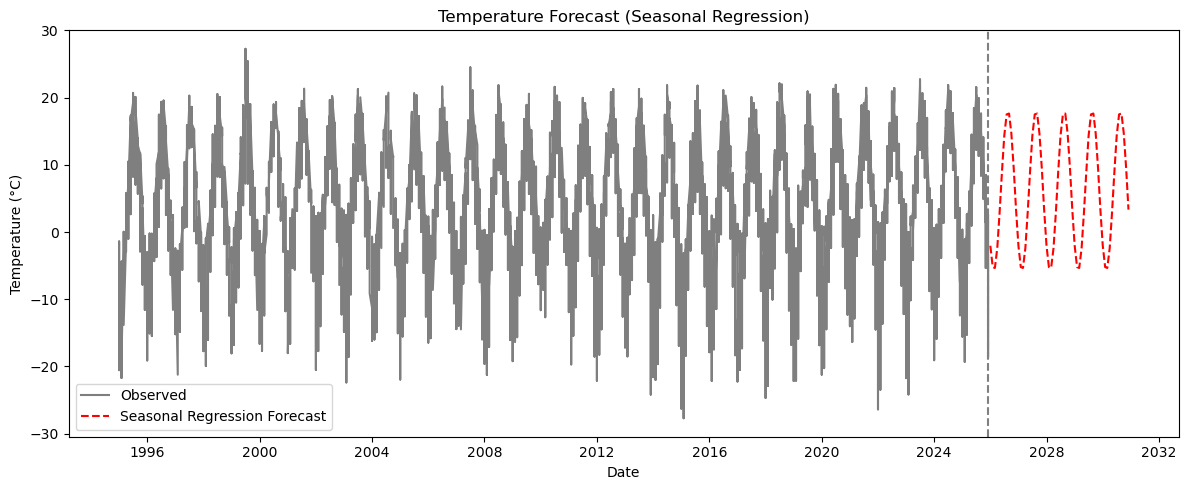

In [7]:
plt.figure(figsize=(12,5))

plt.plot(ts.index, ts.values, color='black', alpha=0.5, label='Observed')
plt.plot(future_dates, forecast, color='red', linestyle='--', label='Seasonal Regression Forecast')

plt.axvline(ts.index[-1], linestyle='--', color='gray')

plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.title('Temperature Forecast (Seasonal Regression)')
plt.legend()

plt.tight_layout()
plt.show()

In [11]:
pred = model.get_prediction(X_future)

In [12]:

forecast_mean = pred.predicted_mean
forecast_ci = pred.summary_frame(alpha=0.05)


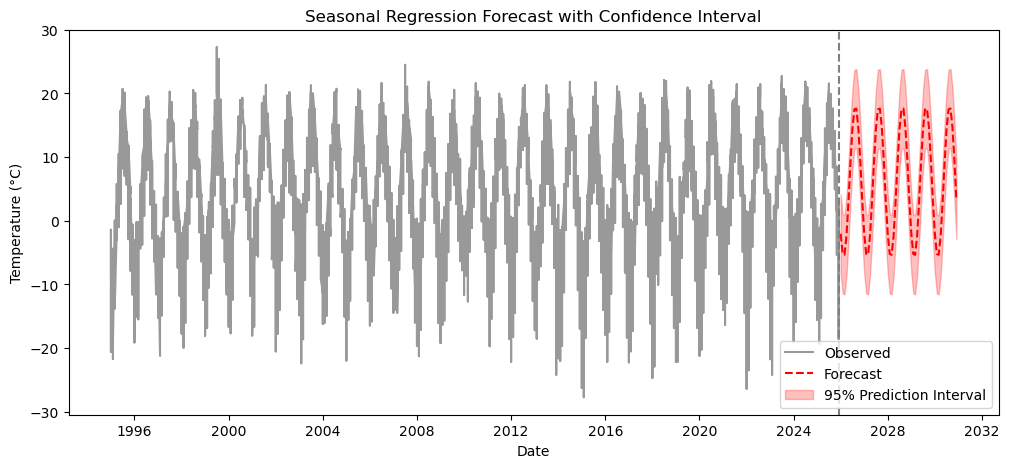

In [14]:
plt.figure(figsize=(12,5))

# Observed
plt.plot(ts.index, ts.values, color="black", alpha=0.4, label="Observed")

# Forecast
plt.plot(future_dates, forecast_mean, color="red", linestyle="--", label="Forecast")

# Confidence interval
plt.fill_between(
    future_dates,
    forecast_ci["obs_ci_lower"],   # ✅ prediction interval
    forecast_ci["obs_ci_upper"],
    color="red",
    alpha=0.25,
    label="95% Prediction Interval"
)

plt.axvline(ts.index[-1], linestyle="--", color="gray")

plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.title("Seasonal Regression Forecast with Confidence Interval")
plt.legend()

plt.show()

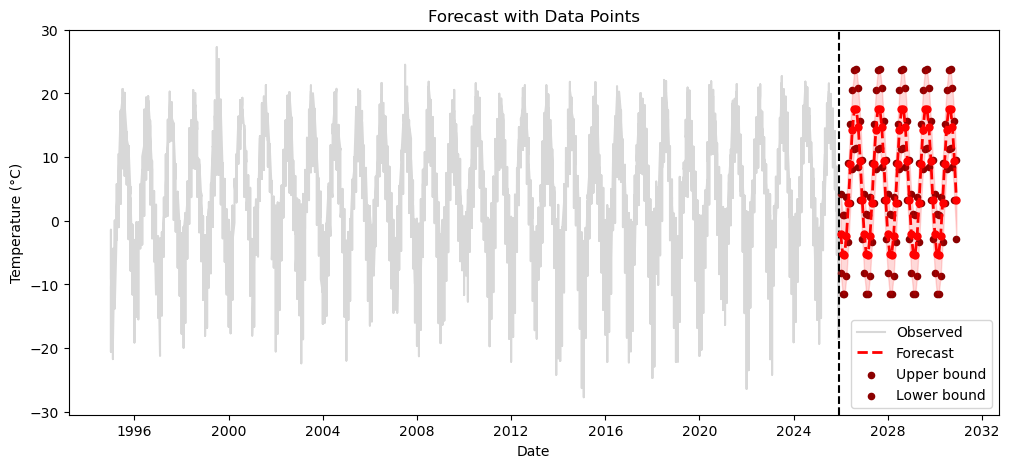

In [17]:
plt.figure(figsize=(12,5))

# Observed (lighter)
plt.plot(ts.index, ts.values, color="gray", alpha=0.3, label="Observed")

# Forecast LINE
plt.plot(
    future_dates,
    forecast_mean,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Forecast"
)

# ✅ ADD FORECAST POINTS
plt.scatter(
    future_dates,
    forecast_mean,
    color="red",
    s=25,
    zorder=3
)

# ✅ ADD UPPER & LOWER POINTS
plt.scatter(
    future_dates,
    forecast_ci["obs_ci_upper"],
    color="darkred",
    s=20,
    label="Upper bound"
)

plt.scatter(
    future_dates,
    forecast_ci["obs_ci_lower"],
    color="darkred",
    s=20,
    label="Lower bound"
)

# Optional: keep band
plt.fill_between(
    future_dates,
    forecast_ci["obs_ci_lower"],
    forecast_ci["obs_ci_upper"],
    color="red",
    alpha=0.15
)

plt.axvline(ts.index[-1], linestyle="--", color="black")

plt.title("Forecast with Data Points")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()

plt.show()

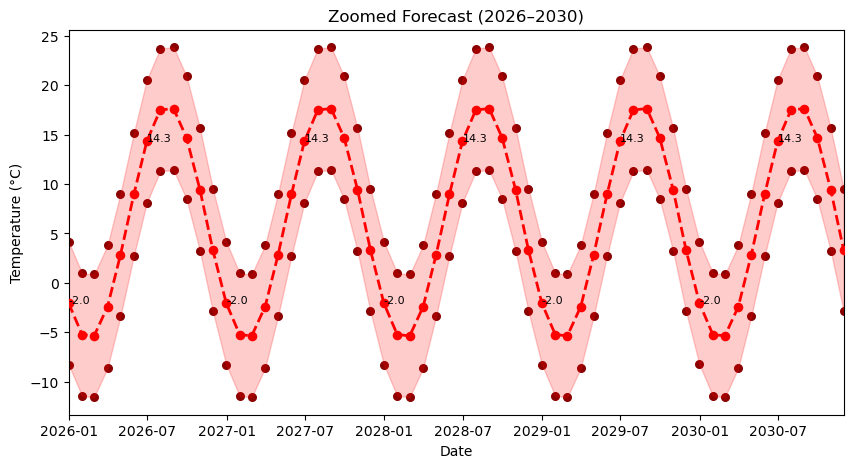

In [19]:
plt.figure(figsize=(10,5))

# Zoomed forecast only
plt.plot(
    future_dates,
    forecast_mean,
    color="red",
    linestyle="--",
    linewidth=2
)

# Points
plt.scatter(
    future_dates,
    forecast_mean,
    color="red",
    s=35,
    zorder=3
)

plt.scatter(
    future_dates,
    forecast_ci["obs_ci_upper"],
    color="darkred",
    s=30
)

plt.scatter(
    future_dates,
    forecast_ci["obs_ci_lower"],
    color="darkred",
    s=30
)

# Confidence band
plt.fill_between(
    future_dates,
    forecast_ci["obs_ci_lower"],
    forecast_ci["obs_ci_upper"],
    color="red",
    alpha=0.2
)

# ✅ IMPORTANT: zoom limits
plt.xlim(future_dates.min(), future_dates.max())

plt.title("Zoomed Forecast (2026–2030)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")

for i in range(0, len(future_dates), 6):  # every 6 months
    plt.text(
        future_dates[i],
        forecast_mean[i],
        f"{forecast_mean[i]:.1f}",
        fontsize=8
    )

plt.show()

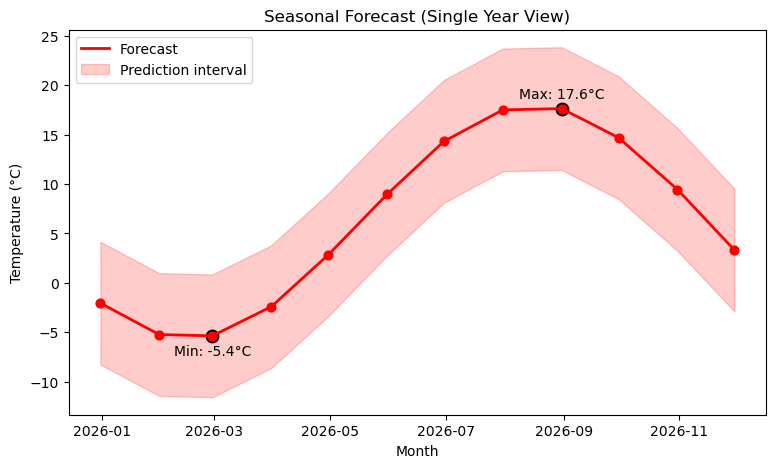

In [21]:
# Pick first forecast year only
n = 12

dates_1yr = future_dates[:n]
mean_1yr = forecast_mean[:n]
upper_1yr = forecast_ci["obs_ci_upper"].values[:n]
lower_1yr = forecast_ci["obs_ci_lower"].values[:n]
plt.figure(figsize=(9,5))

# Forecast curve
plt.plot(
    dates_1yr,
    mean_1yr,
    color="red",
    linewidth=2,
    label="Forecast"
)

# ✅ only ONE set of points (not 3)
plt.scatter(
    dates_1yr,
    mean_1yr,
    color="red",
    s=40,
    zorder=3
)

# Prediction band
plt.fill_between(
    dates_1yr,
    lower_1yr,
    upper_1yr,
    color="red",
    alpha=0.2,
    label="Prediction interval"
)

# ✅ Highlight max & min ONLY
max_idx = mean_1yr.argmax()
min_idx = mean_1yr.argmin()

plt.scatter(dates_1yr[max_idx], mean_1yr[max_idx], color="black", s=80)
plt.scatter(dates_1yr[min_idx], mean_1yr[min_idx], color="black", s=80)

plt.text(
    dates_1yr[max_idx],
    mean_1yr[max_idx] + 1,
    f"Max: {mean_1yr[max_idx]:.1f}°C",
    ha="center"
)

plt.text(
    dates_1yr[min_idx],
    mean_1yr[min_idx] - 2,
    f"Min: {mean_1yr[min_idx]:.1f}°C",
    ha="center"
)

plt.title("Seasonal Forecast (Single Year View)")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.legend()

plt.show()